## Lab 3.2 – Skin Cancer classification: EfficientNetV2 (Lightning)

This notebook provides an example of using the **Lightning** library (newer version of PyTorch Lightning) to build a deep learning model. Objectively, it uses EfficientNet for the skin cancer classification problem.

Dataset consisting of 7 classes: Melanoma(MEL), Melanocytic nevi(NV), Basal cell carcinoma(BCC), Actinic keratoses(AKIEC), Benign keratosis lesions(BKL), Dermatofibroma(DF), and Vascular lesions(VASC).

This example code will consist of:

0. **Setup**
1. **Load Dataset**
2. **Create Model**
3. **Train Model**
4. **Inference & Evaluate**

## 0) Setup
The code below download dataset, imports all required libraries and defines utility functions that will be used in the rest of this notebook.

In [1]:
# !pip install lightning torchinfo scikit-learn

In [ ]:
import os
import cv2
import random
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image
from random import randint
from typing import NewType

# pytorch libraries
import torch
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# lightning library (newer version of pytorch-lightning)
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from torchmetrics.classification import Accuracy

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def set_seed(seed: int = 42):
    # Python random
    random.seed(seed)
    # NumPy
    np.random.seed(seed)
    # PyTorch CPU
    torch.manual_seed(seed)
    # PyTorch GPU
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    L.seed_everything(seed, workers=True)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(2026)

Seed set to 2026


![Lab_3_2_diagram](https://raw.githubusercontent.com/pvateekul/digitalhealth-ai2025/main/image/Lab_3_2_diagram.png)

## 1) Load Dataset

In this step, the dataset is downloaded from GitHub. The directory structure is different from that used in Teachable Machine. Please refer to the following paths:
/content/images/ and /content/GroundTruth.csv

In [4]:
# !wget https://github.com/pvateekul/digitalhealth-ai2025/raw/main/dataset/Ham10000_torch.zip
# !unzip -q -o 'Ham10000_torch.zip'

In [5]:
dataset_path = "/workspaces/Datasets/Digihealth/Ham10000_torch"

df = pd.read_csv(f"{dataset_path}/GroundTruth.csv")
df["image"] = df["image"].apply(lambda x: x + ".jpg")
df = df.drop(columns=["Unnamed: 0"])
df[:10]

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024310.jpg,1,0,0,0,0,0,0
1,ISIC_0024306.jpg,0,1,0,0,0,0,0
2,ISIC_0024331.jpg,0,0,1,0,0,0,0
3,ISIC_0024329.jpg,0,0,0,1,0,0,0
4,ISIC_0024312.jpg,0,0,0,0,1,0,0
5,ISIC_0024318.jpg,0,0,0,0,0,1,0
6,ISIC_0024370.jpg,0,0,0,0,0,0,1
7,ISIC_0024313.jpg,1,0,0,0,0,0,0
8,ISIC_0024307.jpg,0,1,0,0,0,0,0
9,ISIC_0024332.jpg,0,0,1,0,0,0,0


In [6]:
# Set dataset format
lesion_type_dict = {
    "MEL": "Melanoma",
    "NV": "Melanocytic nevi",
    "BCC": "Basal cell carcinoma",
    "AKIEC": "Actinic keratoses",
    "BKL": "Benign keratosis like lesions",
    "DF": "Dermatofibroma",
    "VASC": "Vascular lesions",
}
labels = list(df.columns[1:])
label_list = []
for i in range(len(df)):
    row = list(df.iloc[i])[1:]
    index = np.argmax(row)
    label = lesion_type_dict[labels[index]]
    label_list.append(label)
df["label"] = label_list
df = df.drop(labels, axis=1)
df["label_idx"] = pd.Categorical(df["label"]).codes
df[:10]

,image,label,label_idx
0,ISIC_0024310.jpg,Melanoma,5
1,ISIC_0024306.jpg,Melanocytic nevi,4
2,ISIC_0024331.jpg,Basal cell carcinoma,1
3,ISIC_0024329.jpg,Actinic keratoses,0
4,ISIC_0024312.jpg,Benign keratosis like lesions,2
5,ISIC_0024318.jpg,Dermatofibroma,3
6,ISIC_0024370.jpg,Vascular lesions,6
7,ISIC_0024313.jpg,Melanoma,5
8,ISIC_0024307.jpg,Melanocytic nevi,4
9,ISIC_0024332.jpg,Basal cell carcinoma,1


In [7]:
# Split dataset
train_df, val_df, test_df = df[:210], df[210:280], df[280:350]
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Data Len Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Data Len Train: 210 Val: 70 Test: 70


In [8]:
# Set transform (preprocessing)
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276]),  # nomalize imagenet pretrain
        # augmentation
        transforms.RandomRotation(
            30,
        ),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276]),
    ]
)

In [11]:
# Dataset object
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(os.path.join(f"{dataset_path}/images", self.df["image"][index]))
        y = torch.tensor(int(self.df["label_idx"][index]))

        if self.transform:
            X = self.transform(X)

        return X, y


train_set = HAM10000(train_df, transform=train_transform)
val_set = HAM10000(val_df, transform=val_transform)
test_set = HAM10000(test_df, transform=val_transform)

Label: 5


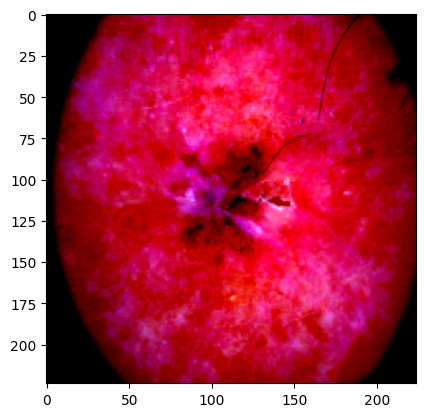

In [12]:
npimg = np.clip(test_set[0][0].cpu().numpy(), 0, 1)
plt.imshow(np.transpose(npimg, (1, 2, 0)))
print(f"Label: {test_set[0][1]}")

In [13]:
# Create Dataloader (dataset object+transform)
# Define the training,val,test sets using the tables and using our defined transitions
BATCH_SIZE = 10
NUM_WORKERS = 2

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=seed_worker
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, worker_init_fn=seed_worker
)
test_loader = DataLoader(test_set, batch_size=7, shuffle=False, num_workers=NUM_WORKERS, worker_init_fn=seed_worker)

print("Data Len Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

Data Len Train: 210 Val: 70 Test: 70


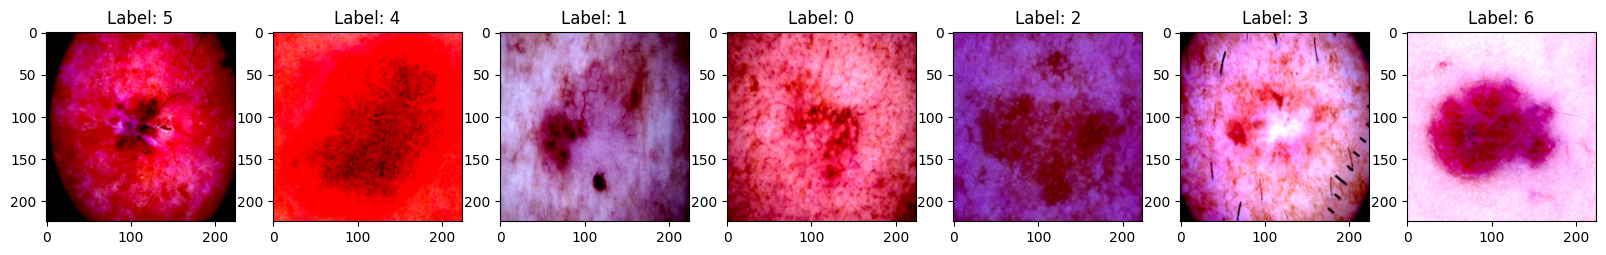

In [14]:
first_batch = next(iter(test_loader))
plt.figure(figsize=(20, 5))
for i in range(7):
    plt.subplot(1, 7, i + 1)
    img = first_batch[0][i]
    # img = img*torch.tensor([0.267, 0.256, 0.276]).mean() + torch.tensor([0.507, 0.487, 0.441]).mean()     # unnormalize
    npimg = img.cpu().numpy()
    npimg = np.clip(npimg, 0, 1)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Label: {first_batch[1][i]}")

## 2) Create Model

In [15]:
# Create model & set loss function
class LitEfficientNetV2(L.LightningModule):
    def __init__(self, num_classes=7, learning_rate=1e-3):
        super().__init__()
        # Load EfficientNetV2 model from torchvision
        self.model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
        # Replace the classifier with a custom layer for our task
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.learning_rate = learning_rate
        self.train_metrics = []
        self.val_metrics = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.accuracy(logits.argmax(dim=1), y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.accuracy(logits.argmax(dim=1), y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True, prog_bar=True)

    def on_train_epoch_end(self):
        # Collect epoch metrics
        train_loss = self.trainer.callback_metrics["train_loss"]
        train_acc = self.trainer.callback_metrics["train_acc"]
        self.train_metrics.append(
            {
                "epoch": self.current_epoch,
                "train_loss": train_loss.item(),
                "train_acc": train_acc.item(),
            }
        )

    def on_validation_epoch_end(self):
        # Update validation metrics
        val_loss = self.trainer.callback_metrics["val_loss"]
        val_acc = self.trainer.callback_metrics["val_acc"]
        self.val_metrics.append(
            {
                "val_loss": val_loss.item(),
                "val_acc": val_acc.item(),
            }
        )

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = LitEfficientNetV2().to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 111MB/s] 


## 3) Train Model

In [16]:
# This cell will take approximately 5-10 minutes to process.
# Train model
checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",  # Monitor validation accuracy
    mode="max",  # Save the model with the highest accuracy
    save_top_k=1,  # Save only the best model
    filename="efficientnetv2-best-{epoch:02d}-{val_acc:.4f}",  # File name format
    verbose=True,  # Print messages when saving
)

trainer = L.Trainer(max_epochs=50, callbacks=[checkpoint_callback])
trainer.fit(net, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/opt/conda/envs/digihealth/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/conda/envs/digihealth/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (21) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Epoch 47, global step 1008: 'val_acc' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 48, global step 1029: 'val_acc' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 49, global step 1050: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.


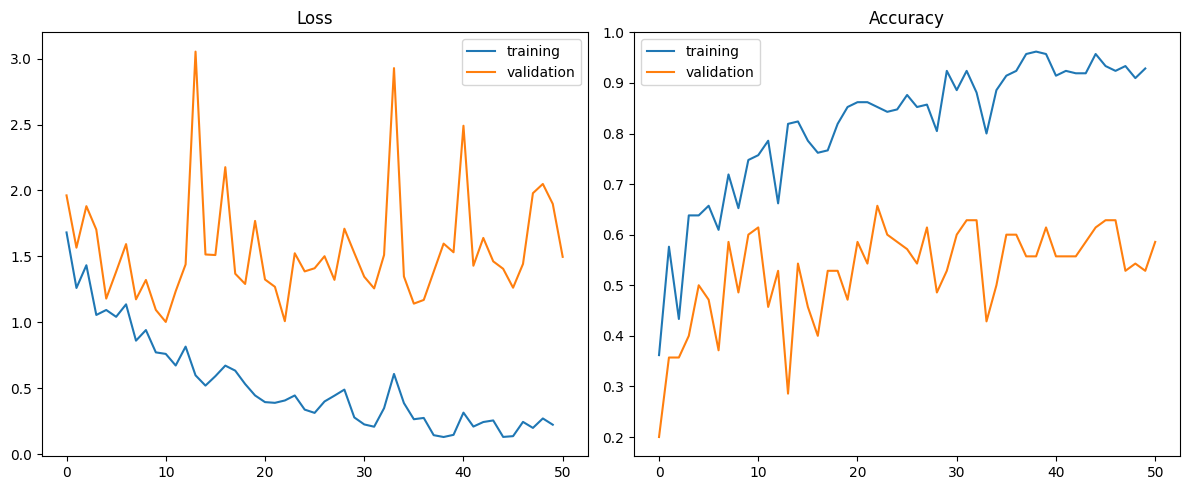

In [17]:
# Plot loss & accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# loss
axs[0].plot([entry["train_loss"] for entry in net.train_metrics], label="training")
axs[0].plot([entry["val_loss"] for entry in net.val_metrics], label="validation")
axs[0].set_title("Loss")
axs[0].legend()
# acc
axs[1].plot([entry["train_acc"] for entry in net.train_metrics], label="training")
axs[1].plot([entry["val_acc"] for entry in net.val_metrics], label="validation")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

## 4) Evaluation & Inference

In [18]:
# Use the best model for inference
print(f"Best model saved at: {checkpoint_callback.best_model_path}")

best_model_path = checkpoint_callback.best_model_path
best_model = LitEfficientNetV2.load_from_checkpoint(best_model_path).to(device)

best_model.eval()
best_model.freeze()

Best model saved at: /workspaces/p32-playgrounds/digihealth/digitalhealth-ai2025/code/Class03_IntroDL/HW/lightning_logs/version_0/checkpoints/efficientnetv2-best-epoch=21-val_acc=0.6571.ckpt


testing ...


  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_103887/3743054296.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inputs[j].cpu() * torch.tensor([0.267, 0.256, 0.276]).mean()
100%|██████████| 10/10 [00:00<00:00, 17.43it/s]


testing loss: 0.9642
              precision    recall  f1-score   support

       AKIEC     0.5000    0.5000    0.5000        10
         BCC     0.7000    0.7000    0.7000        10
         BKL     0.6000    0.6000    0.6000        10
          DF     0.6250    0.5000    0.5556        10
          NV     0.8000    0.8000    0.8000        10
         MEL     0.8750    0.7000    0.7778        10
        VASC     0.7143    1.0000    0.8333        10

    accuracy                         0.6857        70
   macro avg     0.6878    0.6857    0.6810        70
weighted avg     0.6878    0.6857    0.6810        70



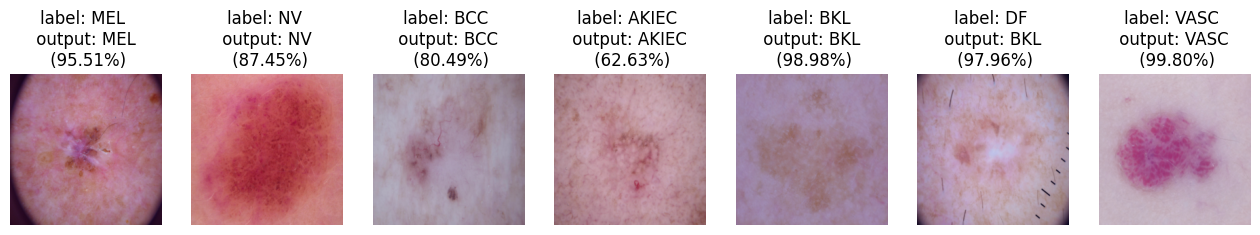

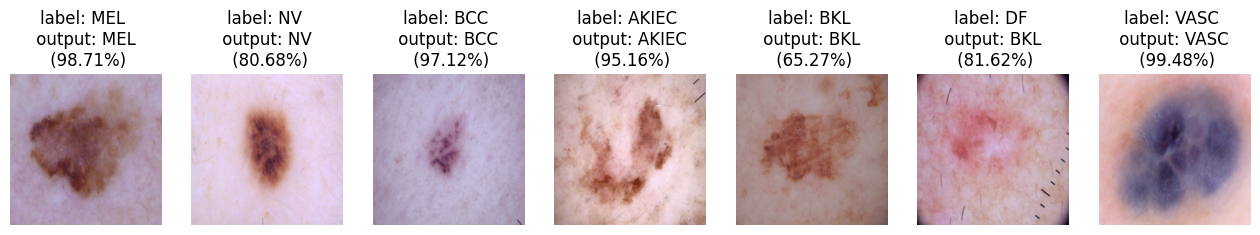

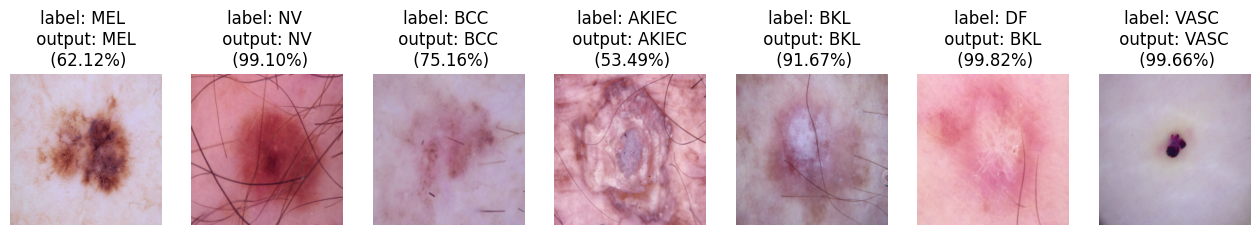

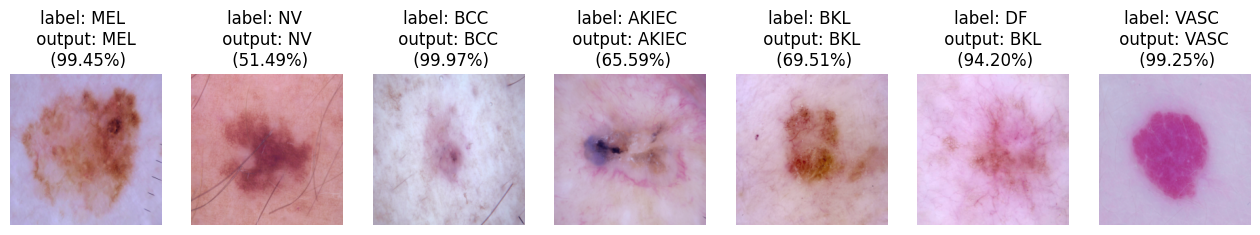

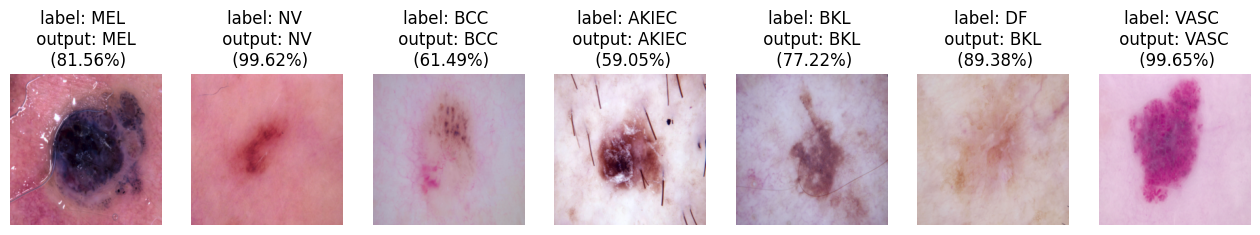

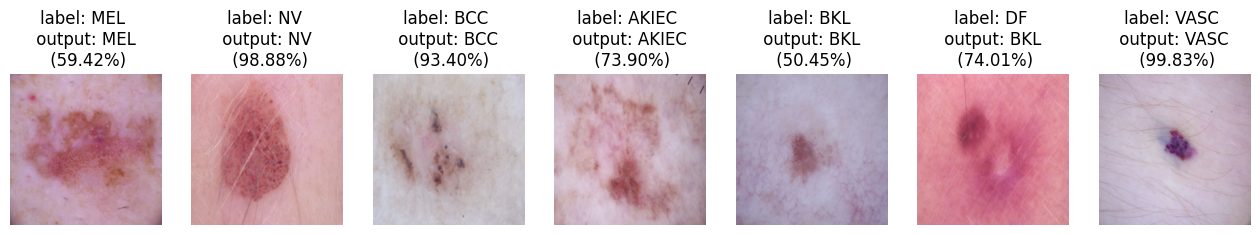

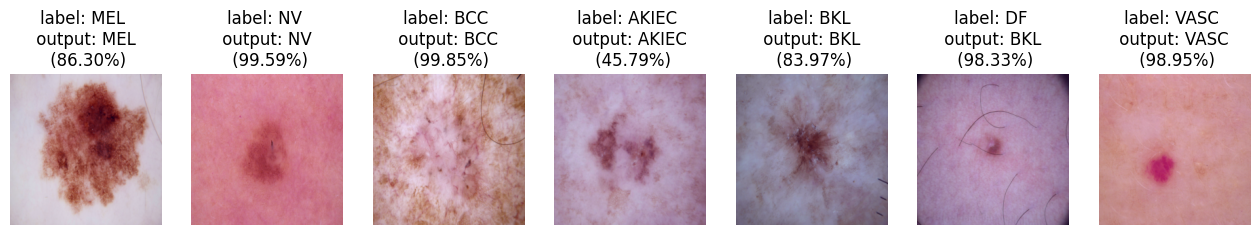

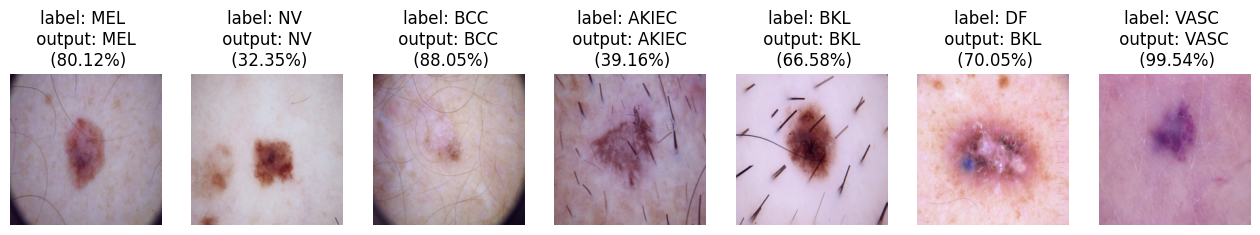

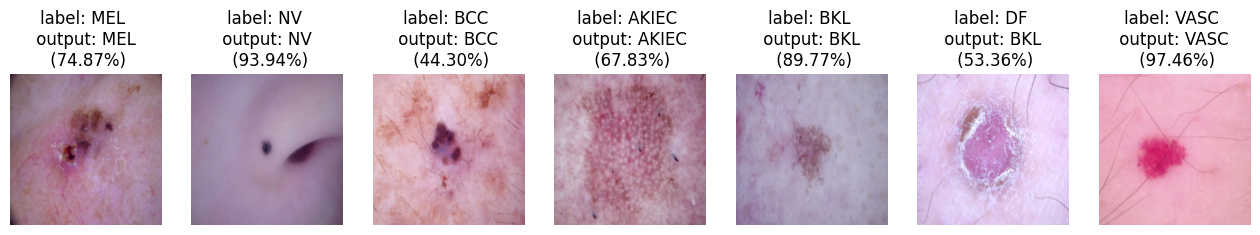

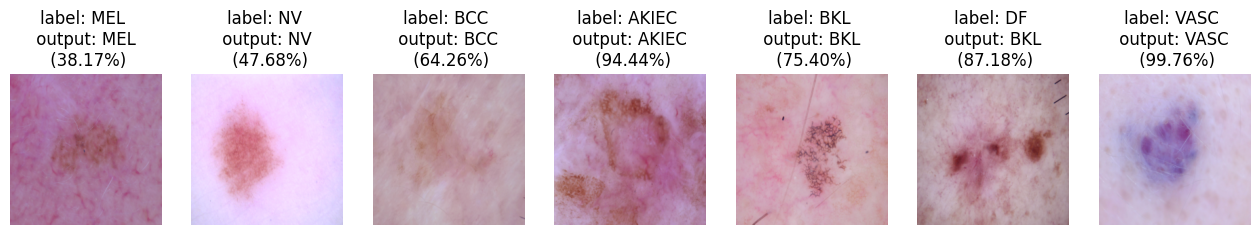

In [19]:
# Evaluate in test dataset
class_names = ["AKIEC", "BCC", "BKL", "DF", "NV", "MEL", "VASC"]
criterion = nn.CrossEntropyLoss()
print("testing ...")
y_predict = list()
y_labels = list()
test_loss = 0.0
n = 0
with torch.no_grad():
    for data in tqdm(test_loader):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        y_labels += list(labels.cpu().numpy())
        y_predict += list(outputs.argmax(dim=1).cpu().numpy())
        # To get probabilities, you can run a softmax on outputs
        y_probs = torch.nn.functional.softmax(outputs, dim=1)
        y_probs = list(y_probs.cpu().numpy())
        n += 1

        plt.figure(figsize=(16, 14))
        for j in range(7):
            plt.subplot(1, 7, j + 1)
            img = (
                inputs[j].cpu() * torch.tensor([0.267, 0.256, 0.276]).mean()
                + torch.tensor([0.507, 0.487, 0.441]).mean().numpy()
            )  # unnormalize
            img = np.clip(img, 0, 1)
            plt.imshow(np.transpose(img, (1, 2, 0)))
            plt.axis("off")
            plt.title(
                f"label: {class_names[labels[j].cpu()]} \n output: {class_names[y_predict[j]]} \n ({y_probs[j][np.argmax(y_probs[j])]*100:.2f}%)"
            )

    # print statistics
    test_loss /= n
    print(f"testing loss: {test_loss:.4}")

    report = classification_report(y_labels, y_predict, target_names=class_names, digits=4)
    M = confusion_matrix(y_labels, y_predict)
    print(report)
    disp = ConfusionMatrixDisplay(confusion_matrix=M, display_labels=class_names)

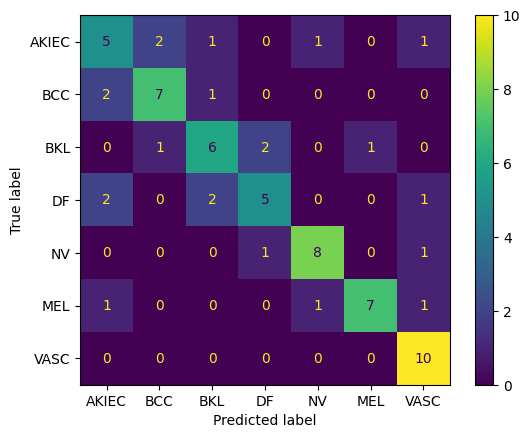

In [20]:
disp.plot()
plt.show()